# Arquitetura do Modelo 3

## Etapa 1 - Importando as bibliotecas

In [1]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 14.7 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import zipfile

cv2.__version__

'4.10.0'

In [3]:
%tensorflow_version 2.x
import tensorflow
tensorflow.__version__

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

In [4]:
!pip install tf_keras

## Etapa 2 - Conectando com o Drive e acessando os arquivos

In [6]:
from google.colab import drive
drive.mount('/content/gdrive')  # Conecta o Google Drive
path = "/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/Material.zip"  # Define o caminho do arquivo Material.zip
zip_object = zipfile.ZipFile(file=path, mode="r")  # Abre o arquivo ZIP em modo de leitura
zip_object.extractall("./")  # Extrai os arquivos para o diretório atual
base_imgs = 'Material/fer2013.zip'  # Define o caminho do arquivo fer2013.zip
zip_object = zipfile.ZipFile(file = base_imgs, mode = "r")  # Abre o arquivo com as imagens em modo de leitura
zip_object.extractall("./")
zip_object.close()  # Fecha o arquivo ZIP

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Etapa 3 - Acessando a base com fotos de expressões faciais



In [8]:
data = pd.read_csv('fer2013/fer2013.csv')  # Carrega o arquivo CSV com os dados do FER2013
data.tail()  # Exibe as últimas linhas do conjunto de dados

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


Text(0.5, 1.0, 'Imagens x emoção')

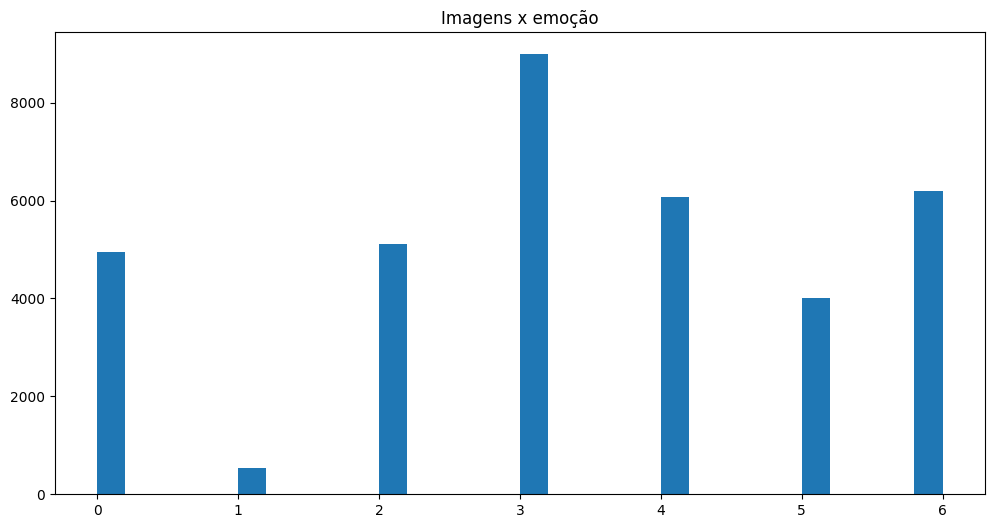

In [9]:
plt.figure(figsize=(12,6))  # Define o tamanho do gráfico
plt.hist(data['emotion'], bins=30)  # Cria um histograma com a quantidade de imagens por emoção
plt.title("Imagens x emoção")  # Define o título do gráfico

# Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

## Etapa 4 - Pré-processamento

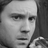

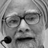

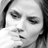

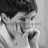

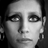

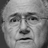

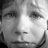

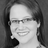

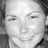

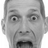

In [11]:
pixels = data['pixels'].tolist()  # Pega os pixels das imagens
largura, altura = 48, 48
faces = []
amostras = 0

for pixel_sequence in pixels:
  face = [int(pixel) for pixel in pixel_sequence.split(' ')]
  face = np.asarray(face).reshape(largura, altura)  # Transforma os pixels em imagem 48x48
  faces.append(face)

  if (amostras < 10):
    cv2_imshow(face)  # Exibe as primeiras imagens

  amostras = amostras + 1

faces = np.asarray(faces)
faces = np.expand_dims(faces, -1)  # Adiciona a dimensão do canal

def normalizar(x, v2=True):
    x = x.astype('float32')
    x = x / 255.0  # Normaliza os valores entre 0 e 1
    return x

faces = normalizar(faces)

emocoes = pd.get_dummies(data['emotion']).values

In [12]:
print("Número total de imagens no dataset: "+str(len(faces)))

Número total de imagens no dataset: 35887


## Etapa 5 - Imports do Tensorflow/Keras

In [13]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, TensorBoard, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json

## Etapa 6 - Dividir em conjuntos para treinamento e validação

In [14]:
x_train, x_test, y_train, y_test = train_test_split(faces, emocoes, test_size=0.1, random_state=42)  # Separa treino e teste
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=41)  # Separa parte do treino para validação

print("Número de imagens no conjunto de treinamento:", len(x_train))
print("Número de imagens no conjunto de testes:", len(x_test))
print("Número de imagens no conjunto de validação:", len(y_val))

Número de imagens no conjunto de treinamento: 29068
Número de imagens no conjunto de testes: 3589
Número de imagens no conjunto de validação: 3230


In [15]:
np.save('mod_xtest', x_test)  # Salva as imagens de teste
np.save('mod_ytest', y_test)  # Salva as classes de teste

## Etapa 7 - Arquitetura do Modelo (CNN)

### Arquitetura do modelo

Implementação original: https://medium.com/themlblog/how-to-do-facial-emotion-recognition-using-a-cnn-b7bbae79cd8f

In [16]:
num_features = 64
num_labels = 7
batch_size = 64
epochs = 100
width, height = 48, 48

model = Sequential()  # Cria o modelo sequencial

# Primeiro bloco convolucional
model.add(Conv2D(num_features, kernel_size=(3, 3), activation='relu', input_shape=(width, height, 1), data_format='channels_last', kernel_regularizer=l2(0.01)))
model.add(Conv2D(num_features, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.5))

# Segundo bloco convolucional
model.add(Conv2D(2*num_features, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*num_features, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.5))

# Terceiro bloco convolucional
model.add(Conv2D(2*2*num_features, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*num_features, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.5))

# Quarto bloco convolucional
model.add(Conv2D(2*2*2*num_features, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*2*num_features, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.5))

model.add(Flatten())  # Transforma os dados em um vetor

# Camadas densas para classificação
model.add(Dense(2*2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*num_features, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_labels, activation='softmax'))  # Camada de saída com as 7 emoções

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,905,863 (22.53 MB)

 Trainable params: 5,902,151 (22.51 MB)

 Non-trainable params: 3,712 (14.50 KB)

## Etapa 8 - Compilando o modelo

In [18]:
model.compile(loss=categorical_crossentropy,
              optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
              metrics=['accuracy'])  # Configura o modelo para o treinamento

arquivo_modelo = "modelo_03_expressoes.h5"
arquivo_modelo_json = "modelo_03_expressoes.json"
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3, verbose=1)  # Reduz a taxa de aprendizado quando não há melhora
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=8, verbose=1, mode='auto')  # Interrompe o treinamento se não houver melhora
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True)  # Salva o melhor modelo

### Salvando a arquitetura do modelo em um arquivo JSON

In [19]:
model_json = model.to_json()  # Converte a estrutura do modelo para JSON
with open(arquivo_modelo_json, "w") as json_file:
    json_file.write(model_json)  # Salva a arquitetura do modelo no arquivo JSON

## Etapa 9 - Treinando o modelo

In [20]:
history = model.fit(np.array(x_train), np.array(y_train),  # Inicia o treinamento do modelo
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(np.array(x_val), np.array(y_val)),  # Usa os dados de validação durante o treinamento
          shuffle=True,
          callbacks=[lr_reducer, early_stopper, checkpointer])  # Aplica os callbacks configurados

Epoch 1/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.1928 - loss: 2.3376
Epoch 1: val_loss improved from None to 1.82776, saving model to modelo_03_expressoes.h5



Epoch 1: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 77s 111ms/step - accuracy: 0.2137 - loss: 2.0004 - val_accuracy: 0.2594 - val_loss: 1.8278 - learning_rate: 0.0010
Epoch 2/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2383 - loss: 1.8403
Epoch 2: val_loss improved from 1.82776 to 1.80090, saving model to modelo_03_expressoes.h5



Epoch 2: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.2438 - loss: 1.8363 - val_accuracy: 0.2594 - val_loss: 1.8009 - learning_rate: 0.0010
Epoch 3/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2462 - loss: 1.8204
Epoch 3: val_loss did not improve from 1.80090
455/455 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.2476 - loss: 1.8140 - val_accuracy: 0.2536 - val_loss: 1.8084 - learning_rate: 0.0010
Epoch 4/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2786 - loss: 1.7737
Epoch 4: val_loss improved from 1.80090 to 1.78198, saving model to modelo_03_expressoes.h5



Epoch 4: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.2863 - loss: 1.7545 - val_accuracy: 0.2613 - val_loss: 1.7820 - learning_rate: 0.0010
Epoch 5/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3325 - loss: 1.6655
Epoch 5: val_loss improved from 1.78198 to 1.75716, saving model to modelo_03_expressoes.h5



Epoch 5: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.3486 - loss: 1.6337 - val_accuracy: 0.2489 - val_loss: 1.7572 - learning_rate: 0.0010
Epoch 6/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3886 - loss: 1.5592
Epoch 6: val_loss improved from 1.75716 to 1.53454, saving model to modelo_03_expressoes.h5


...


Epoch 22: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.6232 - loss: 1.0491 - val_accuracy: 0.6074 - val_loss: 1.0555 - learning_rate: 0.0010
Epoch 23/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6293 - loss: 1.0193
Epoch 23: val_loss did not improve from 1.05547
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6239 - loss: 1.0348 - val_accuracy: 0.5759 - val_loss: 1.1560 - learning_rate: 0.0010
Epoch 24/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6390 - loss: 1.0050
Epoch 24: val_loss improved from 1.05547 to 1.05402, saving model to modelo_03_expressoes.h5



Epoch 24: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.6338 - loss: 1.0162 - val_accuracy: 0.6183 - val_loss: 1.0540 - learning_rate: 0.0010
Epoch 25/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6386 - loss: 0.9964
Epoch 25: val_loss did not improve from 1.05402
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6387 - loss: 1.0020 - val_accuracy: 0.5969 - val_loss: 1.0967 - learning_rate: 0.0010
Epoch 26/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6452 - loss: 0.9793
Epoch 26: val_loss improved from 1.05402 to 1.03707, saving model to modelo_03_expressoes.h5



Epoch 26: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6469 - loss: 0.9780 - val_accuracy: 0.6229 - val_loss: 1.0371 - learning_rate: 0.0010
Epoch 27/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6599 - loss: 0.9488
Epoch 27: val_loss did not improve from 1.03707
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6529 - loss: 0.9676 - val_accuracy: 0.6192 - val_loss: 1.0639 - learning_rate: 0.0010
Epoch 28/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6592 - loss: 0.9400
Epoch 28: val_loss improved from 1.03707 to 1.00726, saving model to modelo_03_expressoes.h5



Epoch 28: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6594 - loss: 0.9431 - val_accuracy: 0.6334 - val_loss: 1.0073 - learning_rate: 0.0010
Epoch 29/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6668 - loss: 0.9125
Epoch 29: val_loss did not improve from 1.00726
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6648 - loss: 0.9225 - val_accuracy: 0.6201 - val_loss: 1.0577 - learning_rate: 0.0010
Epoch 30/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6790 - loss: 0.9005
Epoch 30: val_loss did not improve from 1.00726
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6747 - loss: 0.9090 - val_accuracy: 0.5963 - val_loss: 1.1067 - learning_rate: 0.0010
Epoch 31/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6797 - loss: 0.8919
Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0009000000427477062.

Epoch 31: val_loss did not improve from 1.00726
455/455 ━━━━━━━━━━━━━━


Epoch 36: finished saving model to modelo_03_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.7187 - loss: 0.7826 - val_accuracy: 0.6560 - val_loss: 0.9899 - learning_rate: 8.1000e-04
Epoch 37/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7325 - loss: 0.7460
Epoch 37: val_loss did not improve from 0.98986
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.7283 - loss: 0.7570 - val_accuracy: 0.6483 - val_loss: 1.0235 - learning_rate: 8.1000e-04
Epoch 38/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7417 - loss: 0.7302
Epoch 38: val_loss did not improve from 0.98986
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.7343 - loss: 0.7415 - val_accuracy: 0.6294 - val_loss: 1.0387 - learning_rate: 8.1000e-04
Epoch 39/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7436 - loss: 0.7178
Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0007290000503417104.

Epoch 39: val_loss did not improve from 0.98986
455/455 ━━

## Gerando gráfico da melhora em cada etapa do treinamento

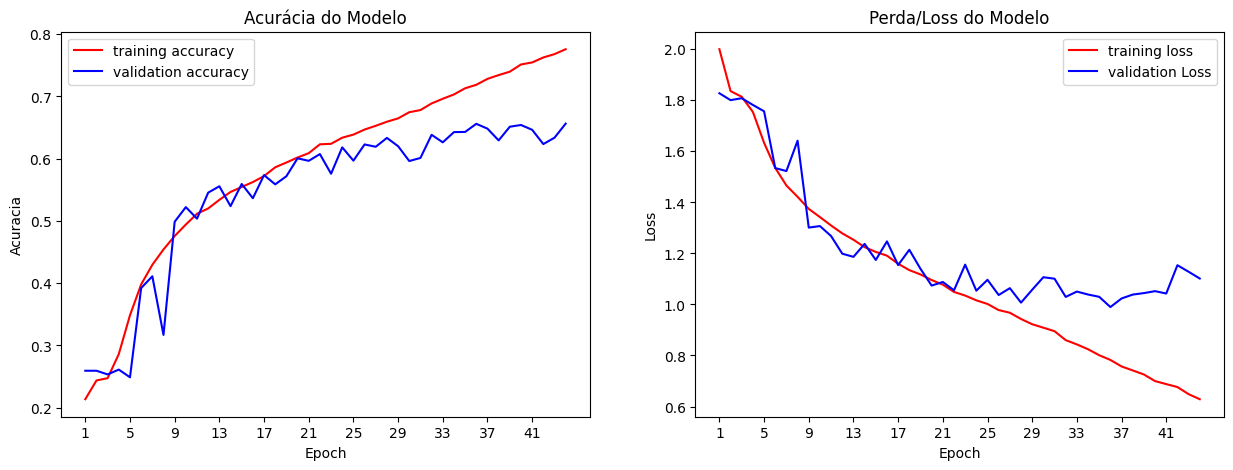

In [22]:
def plota_historico_modelo(historico_modelo):
    fig, axs = plt.subplots(1,2,figsize=(15,5))  # Cria os gráficos de acurácia e perda
    axs[0].plot(range(1,len(historico_modelo.history['accuracy'])+1),
                historico_modelo.history['accuracy'],'r')
    axs[0].plot(range(1,len(historico_modelo.history['val_accuracy'])+1),
                historico_modelo.history['val_accuracy'],'b')
    axs[0].set_title('Acurácia do Modelo')
    axs[0].set_ylabel('Acuracia')
    axs[0].set_xlabel('Epoch')
    axs[0].set_xticks(np.arange(1,
                               len(historico_modelo.history['accuracy'])+1,
                               max(1, len(historico_modelo.history['accuracy'])//10)))
    axs[0].legend(['training accuracy', 'validation accuracy'], loc='best')

    axs[1].plot(range(1,len(historico_modelo.history['loss'])+1),
                historico_modelo.history['loss'],'r')
    axs[1].plot(range(1,len(historico_modelo.history['val_loss'])+1),
                historico_modelo.history['val_loss'],'b')
    axs[1].set_title('Perda/Loss do Modelo')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_xticks(np.arange(1,
                               len(historico_modelo.history['loss'])+1,
                               max(1, len(historico_modelo.history['loss'])//10)))
    axs[1].legend(['training loss', 'validation Loss'], loc='best')
    fig.savefig('historico_modelo_mod01.png')  # Salva o gráfico gerado
    plt.show()

plota_historico_modelo(history)  # Exibe o histórico do treinamento

### Verificando a acurácia do modelo

In [23]:
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size)
print("Acurácia: " + str(scores[1]))
print("Perda/Loss: " + str(scores[0]))

57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.6408 - loss: 1.1558
Acurácia: 0.6408470273017883
Perda/Loss: 1.1558117866516113


## Carregaremos os dados para gerar a matriz de confusão

In [24]:
true_y=[]
pred_y=[]

x = np.load('mod_xtest.npy')  # Carrega as imagens de teste
y = np.load('mod_ytest.npy')  # Carrega as classes reais
json_file = open(arquivo_modelo_json, 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)  # Reconstrói o modelo pelo JSON
loaded_model.load_weights(arquivo_modelo)  # Carrega os pesos do modelo
y_pred= loaded_model.predict(x)  # Realiza as previsões
yp = y_pred.tolist()
yt = y.tolist()
count = 0

for i in range(len(y)):
    yy = max(yp[i])
    yyt = max(yt[i])
    pred_y.append(yp[i].index(yy))
    true_y.append(yt[i].index(yyt))

    if(yp[i].index(yy)== yt[i].index(yyt)):
        count+=1

acc = (count/len(y))*100  # Calcula a acurácia no conjunto de teste

np.save('truey__mod01', true_y)
np.save('predy__mod01', pred_y)
print("Acurácia no conjunto de testes: "+str(acc)+"%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
Acurácia no conjunto de testes: 63.36026748397883%


## Gerando a Matriz de Confusão

In [25]:
from sklearn.metrics import confusion_matrix

y_true = np.load('truey__mod01.npy')  # Carrega os valores reais
y_pred = np.load('predy__mod01.npy')  # Carrega os valores previstos
cm = confusion_matrix(y_true, y_pred)  # Gera a matriz de confusão
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]
titulo='Matriz de Confusão'
print(cm)  # Exibe a matriz

[[268   3  51  21  84   9  62]
 [ 18  19   9   0   5   0   1]
 [ 64   5 220  20 149  43  44]
 [ 21   0  17 751  30  14  48]
 [ 64   0  57  19 344   1 103]
 [ 10   0  75  32   6 278  13]
 [ 36   1  29  38 107   6 394]]


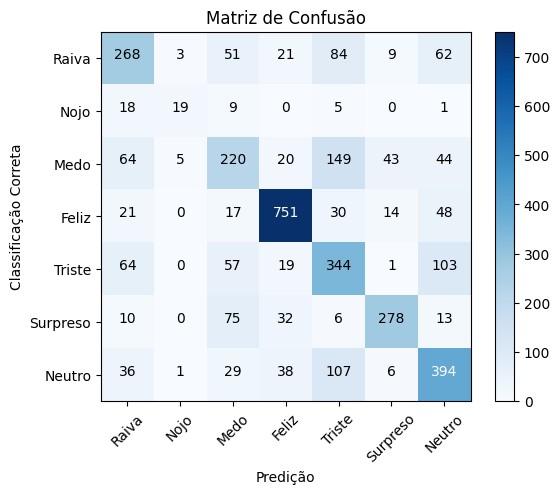

In [26]:
import itertools

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)  # Exibe a matriz de confusão
plt.title(titulo)
plt.colorbar()
tick_marks = np.arange(len(expressoes))
plt.xticks(tick_marks, expressoes, rotation=45)
plt.yticks(tick_marks, expressoes)
fmt = 'd'
thresh = cm.max() / 2.

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")  # Escreve os valores dentro da matriz

plt.ylabel('Classificação Correta')
plt.xlabel('Predição')
plt.savefig('matriz_confusao_mod01.png')  # Salva a matriz como imagem
plt.show()

## Testando brevemente o modelo

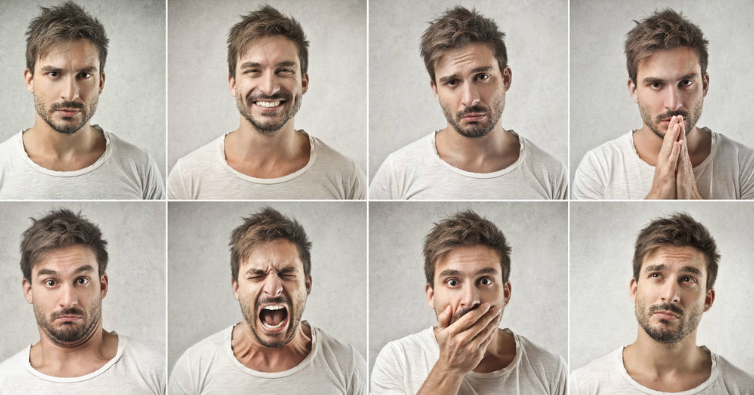

In [27]:
imagem = cv2.imread("Material/testes/teste02.jpg")  # Carrega a imagem para o teste
cv2_imshow(imagem)  # Exibe a imagem

In [28]:
model = load_model("modelo_03_expressoes.h5") # carrega o modelo
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size)
print("Perda/Loss: " + str(scores[0]))
print("Acurácia: " + str(scores[1]))

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6336 - loss: 1.0518
Perda/Loss: 1.0517910718917847
Acurácia: 0.6336026787757874


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


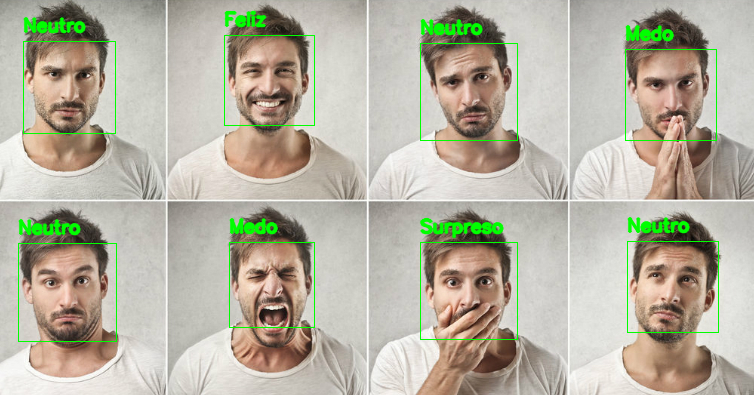

In [29]:
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]

original = imagem.copy()  # Faz uma cópia da imagem original
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)  # Converte a imagem para escala de cinza
face_cascade = cv2.CascadeClassifier('Material/haarcascade_frontalface_default.xml')  # Carrega o detector de faces
faces = face_cascade.detectMultiScale(gray, 1.1, 3)  # Detecta as faces na imagem

for (x, y, w, h) in faces:
    cv2.rectangle(original, (x, y), (x + w, y + h), (0, 255, 0), 1)
    roi_gray = gray[y:y + h, x:x + w]  # Recorta a região do rosto
    roi_gray = roi_gray.astype("float") / 255.0  # Normaliza os pixels
    cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray, (48, 48)), -1), 0)

    cv2.normalize(cropped_img, cropped_img, alpha=0, beta=1,
                  norm_type=cv2.NORM_L2, dtype=cv2.CV_32F)

    prediction = model.predict(cropped_img)[0]  # Faz a predição da emoção
    cv2.putText(original, expressoes[int(np.argmax(prediction))], (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

cv2_imshow(original)  # Exibe o resultado